<a href="https://colab.research.google.com/github/cemonce/MASTER-CIENCIA-DE-DATOS/blob/main/graficos_venta_viviendas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [5]:
from google.colab import files
uploaded = files.upload()

Saving 6150bsc.csv to 6150bsc (1).csv


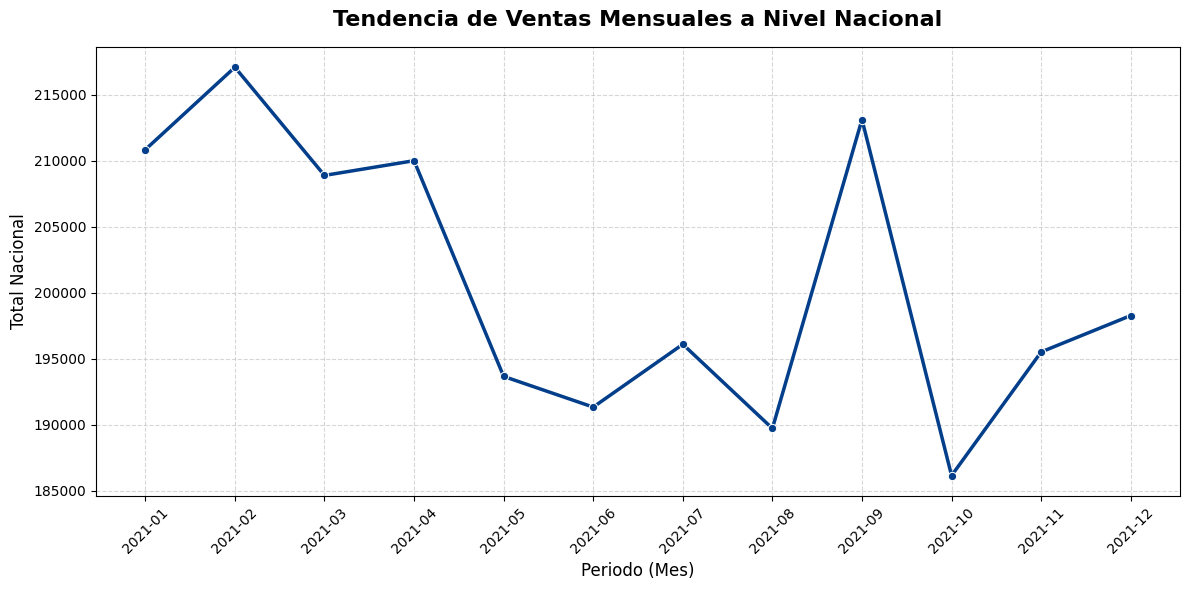

In [7]:
# 1. Cargar csv
df = pd.read_csv('6150bsc.csv', sep=';', encoding='latin1')

# 2. Corregir el formato numérico (quitar los puntos de los miles y convertir a entero)
df['Total'] = df['Total'].astype(str).str.replace('.', '', regex=False).astype(int)

# 3. Convertir el formato '2021M12' a una fecha real
df['Fecha'] = pd.to_datetime(df['Periodo'], format='%YM%m')

# 4. Agrupar por fecha y sumar a nivel nacional
# Al usar groupby sobre la columna limpia 'Fecha', se ordenará cronológicamente de enero a diciembre
tendencia_mensual = df.groupby('Fecha')['Total'].sum().reset_index()

# 5. Formatear la fecha como '2021-12' para que quede estético en el gráfico
tendencia_mensual['Mes'] = tendencia_mensual['Fecha'].dt.strftime('%Y-%m')

# 6. Crear el gráfico de tendencia
plt.figure(figsize=(12, 6))
sns.lineplot(data=tendencia_mensual, x='Mes', y='Total', marker='o', linewidth=2.5, color='#023e8a')

# Configuración y diseño visual
plt.title('Tendencia de Ventas Mensuales a Nivel Nacional', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Periodo (Mes)', fontsize=12)
plt.ylabel('Total Nacional', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)

# Optimizar espacio y mostrar gráfico
plt.tight_layout()
plt.show()

/tmp/ipykernel_1095/2461682081.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


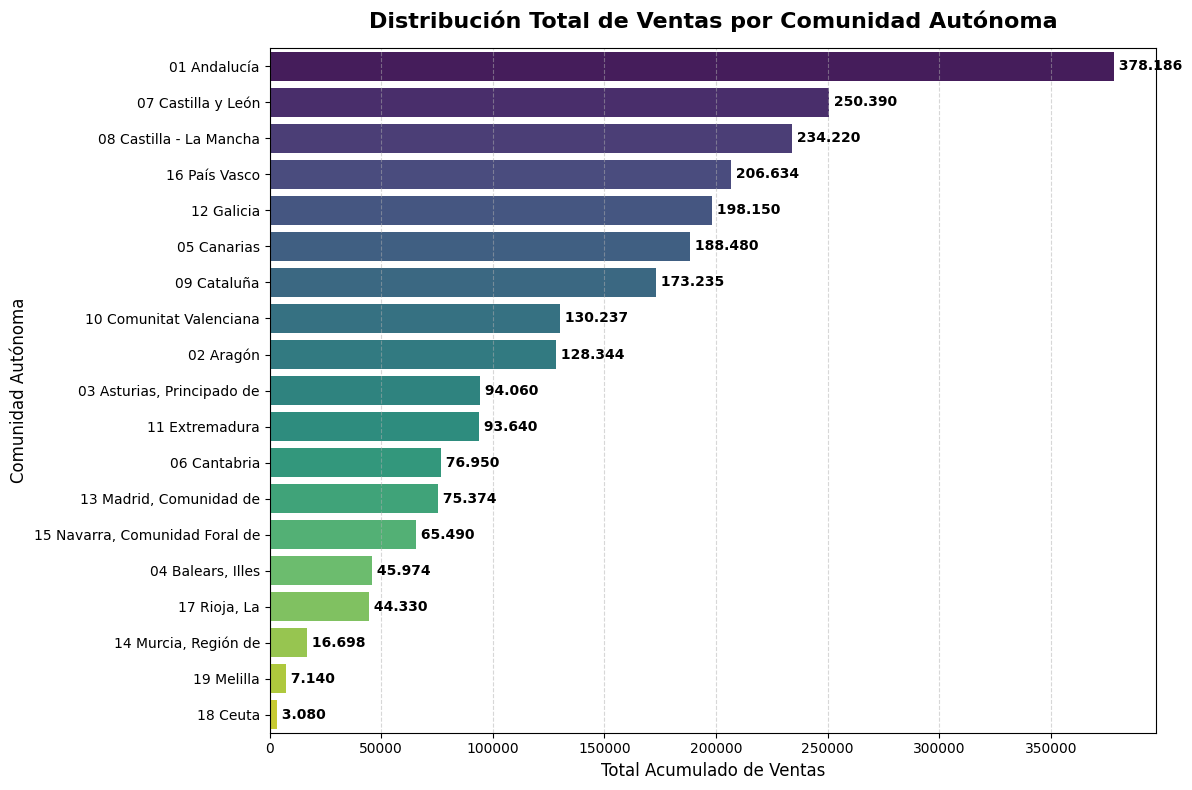


--- Tabla de Ventas por Comunidad Autónoma ---
Comunidades y Ciudades Autónomas  Total
                    01 Andalucía 378186
              07 Castilla y León 250390
         08 Castilla - La Mancha 234220
                   16 País Vasco 206634
                      12 Galicia 198150
                     05 Canarias 188480
                     09 Cataluña 173235
         10 Comunitat Valenciana 130237
                       02 Aragón 128344
      03 Asturias, Principado de  94060
                  11 Extremadura  93640
                    06 Cantabria  76950
         13 Madrid, Comunidad de  75374
  15 Navarra, Comunidad Foral de  65490
               04 Balears, Illes  45974
                    17 Rioja, La  44330
            14 Murcia, Región de  16698
                      19 Melilla   7140
                        18 Ceuta   3080


In [9]:
# 1. Cargar el CSV con su separador correcto
df = pd.read_csv('6150bsc.csv', sep=';', encoding='latin1')

# 2. Limpiar el formato numérico de la columna Total
df['Total'] = df['Total'].astype(str).str.replace('.', '', regex=False).astype(int)

# 3. Agrupar por Comunidad Autónoma y sumar el total de ventas
ventas_por_ccaa = df.groupby('Comunidades y Ciudades Autónomas')['Total'].sum().reset_index()

# 4. Ordenar los resultados de mayor a menor volumen de ventas
ventas_por_ccaa = ventas_por_ccaa.sort_values(by='Total', ascending=False)

# 5. Crear el gráfico de barras horizontales
plt.figure(figsize=(12, 8))
sns.barplot(
    data=ventas_por_ccaa,
    x='Total',
    y='Comunidades y Ciudades Autónomas',
    palette='viridis' # Degradado de color automático según el volumen
)

# Configuración visual
plt.title('Distribución Total de Ventas por Comunidad Autónoma', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Total Acumulado de Ventas', fontsize=12)
plt.ylabel('Comunidad Autónoma', fontsize=12)
plt.grid(True, axis='x', linestyle='--', alpha=0.5) # Rejilla solo vertical para seguir las barras

# Añadir las etiquetas con el valor exacto al final de cada barra
for index, value in enumerate(ventas_por_ccaa['Total']):
    plt.text(value, index, f' {value:,}'.replace(',', '.'), va='center', fontsize=10, fontweight='semibold')

# Ajustar y mostrar
plt.tight_layout()
plt.show()

# 6. Opcional: Mostrar la tabla de datos ordenada en la consola
print("\n--- Tabla de Ventas por Comunidad Autónoma ---")
print(ventas_por_ccaa.to_string(index=False))

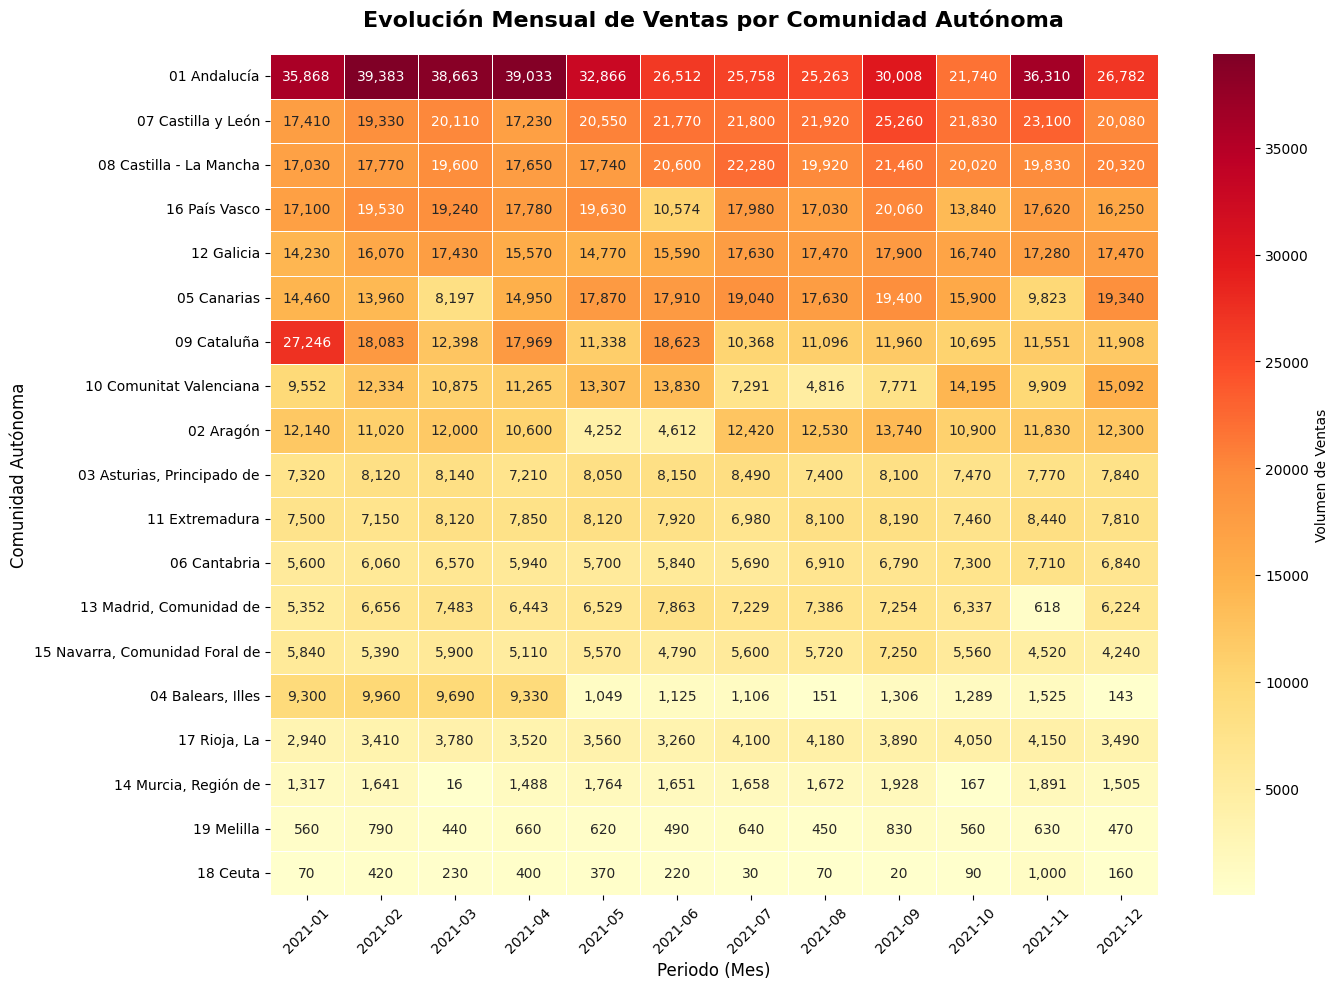

In [11]:
# 1. Cargar el CSV con su separador correcto
df = pd.read_csv('6150bsc.csv', sep=';', encoding='latin1')

# 2. Limpiar el formato numérico de la columna Total
df['Total'] = df['Total'].astype(str).str.replace('.', '', regex=False).astype(int)

# 3. Convertir la columna Periodo a un formato de fecha real
df['Fecha'] = pd.to_datetime(df['Periodo'], format='%YM%m')

# 4. Formatear la fecha a un texto limpio 'Año-Mes' (ej. 2021-01)
df['Mes'] = df['Fecha'].dt.strftime('%Y-%m')

# 5. Agrupar por CCAA y por Mes para sumar los totales correspondientes
agrupado = df.groupby(['Comunidades y Ciudades Autónomas', 'Mes'])['Total'].sum().reset_index()

# 6. Reestructurar los datos en una matriz (Filas = CCAA, Columnas = Meses)
# Esto es necesario para alimentar el mapa de calor
matriz_ventas = agrupado.pivot(
    index='Comunidades y Ciudades Autónomas',
    columns='Mes',
    values='Total'
)

# Opcional: Ordenar las Comunidades Autónomas por volumen total para mejor organización visual
matriz_ventas = matriz_ventas.loc[matriz_ventas.sum(axis=1).sort_values(ascending=False).index]

# 7. Diseñar el mapa de calor (Heatmap)
plt.figure(figsize=(14, 10))
sns.heatmap(
    matriz_ventas,
    cmap='YlOrRd',       # Paleta de colores: de amarillo (bajo) a rojo (alto)
    annot=True,          # Muestra el número exacto dentro de cada celda
    fmt=',.0f',          # Formato numérico sin decimales
    linewidths=0.5,      # Línea sutil de separación entre celdas
    cbar_kws={'label': 'Volumen de Ventas'}
)

# Configuración y títulos
plt.title('Evolución Mensual de Ventas por Comunidad Autónoma', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Periodo (Mes)', fontsize=12)
plt.ylabel('Comunidad Autónoma', fontsize=12)
plt.xticks(rotation=45)

# Ajustar y mostrar
plt.tight_layout()
plt.show()